In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


In [ ]:
## 1. Data Quality Report

Before cleaning the dataset, a data quality assessment is performed to identify missing values, duplicate rows, data type issues, and possible value-range anomalies.

In [8]:
## Check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
## Check missing values

missing_values = df.isnull().sum()
missing_values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [12]:
## Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
## Check numerical ranges

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
## Check unique values in categorical columns

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


Name:
Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Ticket:
Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count

C:\Users\PROFESSOR\AppData\Local\Temp\ipykernel_5816\69470996.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [15]:
## Create a Data Quality Summary

quality_report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Missing Values': df.isnull().sum().values,
    'Missing %': ((df.isnull().sum() / len(df)) * 100).round(2).values,
    'Unique Values': df.nunique().values
})

quality_report

,Column,Data Type,Missing Values,Missing %,Unique Values
0,PassengerId,int64,0,0.00,891
1,Survived,int64,0,0.00,2
2,Pclass,int64,0,0.00,3
3,Name,str,0,0.00,891
4,Sex,str,0,0.00,2
5,Age,float64,177,19.87,88
6,SibSp,int64,0,0.00,7
7,Parch,int64,0,0.00,7
8,Ticket,str,0,0.00,681
9,Fare,float64,0,0.00,248


In [ ]:
## 2. Missing Data Handling

The dataset contains missing values in three columns: Age, Cabin, and Embarked.

- **Age:** Missing values will be replaced using the median because Age is a numerical variable and the median is less affected by extreme values than the mean.
- **Cabin:** A large proportion of Cabin values are missing. Instead of deleting a large number of records, missing Cabin values will be replaced with "Unknown" to preserve the available passenger records.
- **Embarked:** Only two values are missing, so they will be replaced with the mode because Embarked is a categorical variable.

In [17]:
## Handle Age

age_median = df['Age'].median()

print("Age median:", age_median)

Age median: 28.0


In [19]:
## missing values:

df['Age'] = df['Age'].fillna(age_median)

In [20]:
## Check:

print("Missing Age values after cleaning:", df['Age'].isnull().sum())

Missing Age values after cleaning: 0


In [23]:
## Handle Cabin
## Unknown".

df['Cabin'] = df['Cabin'].fillna('Unknown')

In [24]:
print("Missing Cabin values after cleaning:", df['Cabin'].isnull().sum())

Missing Cabin values after cleaning: 0


In [26]:
## Handle Embarked

embarked_mode = df['Embarked'].mode()[0]

print("Embarked mode:", embarked_mode)

Embarked mode: S


In [27]:
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

In [28]:
print("Missing Embarked values after cleaning:", df['Embarked'].isnull().sum())

Missing Embarked values after cleaning: 0


In [29]:
## Verify ALL missing values

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [30]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [31]:
## 3. Duplicate Data Handling

The dataset was checked for duplicate rows. No duplicate rows were found, so no rows were removed during the duplicate-cleaning process.

SyntaxError: invalid syntax (690118156.py, line 3)

In [32]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

Duplicate rows found: 0


In [33]:
df = df.drop_duplicates()

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (891, 12)


In [ ]:
## 4. Inconsistent Formatting Check

Categorical columns are examined for inconsistent spelling, capitalization, or unexpected values. This helps ensure that categories are represented consistently before analysis.

In [34]:
print("Sex values:")
print(df['Sex'].value_counts())

print("\nEmbarked values:")
print(df['Embarked'].value_counts())

print("\nPclass values:")
print(df['Pclass'].value_counts())

Sex values:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked values:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Pclass values:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [36]:
print("Number of unique Ticket values:", df['Ticket'].nunique())

Number of unique Ticket values: 681


In [ ]:
## 5. Outlier Detection

Outliers are examined in the numerical variables Age and Fare using the Interquartile Range (IQR) method. The IQR method identifies observations that fall below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR.

In [37]:
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df['Age'] < lower_age) |
    (df['Age'] > upper_age)
]

print("Age lower bound:", lower_age)
print("Age upper bound:", upper_age)
print("Number of Age outliers:", len(age_outliers))

Age lower bound: 2.5
Age upper bound: 54.5
Number of Age outliers: 66


In [38]:
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[
    (df['Fare'] < lower_fare) |
    (df['Fare'] > upper_fare)
]

print("Fare lower bound:", lower_fare)
print("Fare upper bound:", upper_fare)
print("Number of Fare outliers:", len(fare_outliers))

Fare lower bound: -26.724
Fare upper bound: 65.6344
Number of Fare outliers: 116


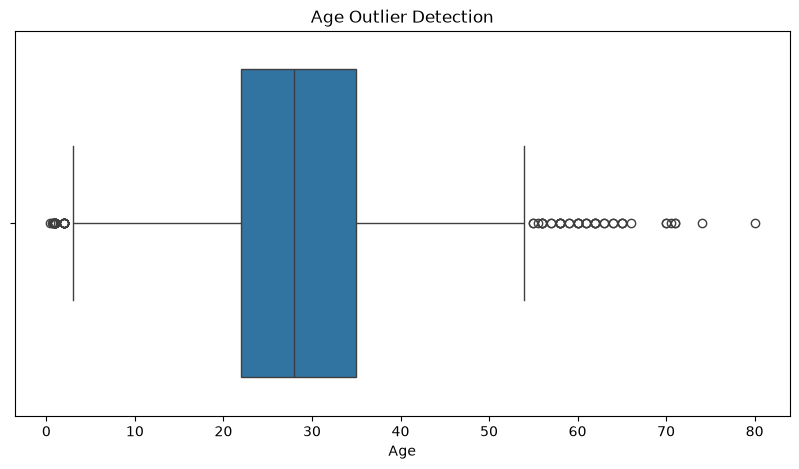

In [39]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Age'])

plt.title('Age Outlier Detection')
plt.xlabel('Age')

plt.show()

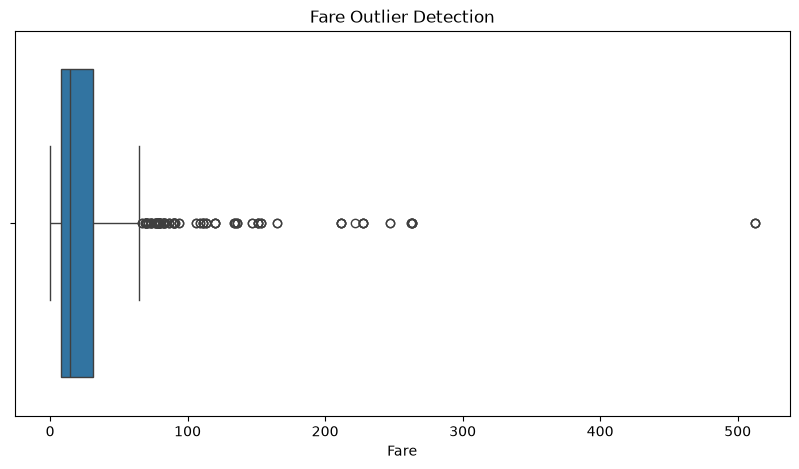

In [40]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Fare'])

plt.title('Fare Outlier Detection')
plt.xlabel('Fare')

plt.show()

In [41]:
## Outlier Treatment

The IQR method identified 66 potential outliers in Age and 116 potential outliers in Fare.

These observations were not automatically removed because an IQR outlier does not necessarily represent an incorrect value. In this dataset, higher fares and older passenger ages can be legitimate observations. Removing them could result in loss of useful information.

Therefore, the identified outliers were retained, but their presence was documented as part of the data-quality assessment.

SyntaxError: invalid syntax (489943029.py, line 3)

In [ ]:
## 6. Data Type Validation

The data types of all columns are checked to ensure that numerical, categorical, and text variables are stored using appropriate formats.

In [42]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [44]:
print("Age:", df['Age'].dtype)
print("Fare:", df['Fare'].dtype)
print("Survived:", df['Survived'].dtype)
print("Pclass:", df['Pclass'].dtype)
print("Sex:", df['Sex'].dtype)
print("Embarked:", df['Embarked'].dtype)

Age: float64
Fare: float64
Survived: int64
Pclass: int64
Sex: str
Embarked: str


In [45]:
print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Dataset shape: (891, 12)
Total missing values: 0
Total duplicate rows: 0


In [47]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [ ]:
### Data Type Validation — Observation

The data types were reviewed after the cleaning process. Numerical variables such as PassengerId, Survived, Pclass, SibSp, and Parch are stored as integers, while Age and Fare are stored as floating-point values. Text-based variables such as Name, Sex, Ticket, Cabin, and Embarked are stored as strings. The data types are appropriate for the current analysis, so no unnecessary type conversions were performed.

In [48]:
## Final Data Quality Check

print("Final Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (891, 12)
Total Missing Values: 0
Total Duplicate Rows: 0


In [49]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [ ]:
## 7. Before vs After Data Quality Summary

The dataset was evaluated before and after the cleaning process to measure the improvements in data quality.

In [50]:
before_missing = 177 + 687 + 2
before_duplicates = 0
after_missing = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()

comparison = pd.DataFrame({
    'Metric': [
        'Total Rows',
        'Total Columns',
        'Missing Values',
        'Duplicate Rows'
    ],
    'Before Cleaning': [
        891,
        12,
        before_missing,
        before_duplicates
    ],
    'After Cleaning': [
        df.shape[0],
        df.shape[1],
        after_missing,
        after_duplicates
    ]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Total Rows,891,891
1,Total Columns,12,12
2,Missing Values,866,0
3,Duplicate Rows,0,0


In [ ]:
## 8. Export Cleaned Dataset

The cleaned dataset is saved as a separate CSV file so that the original dataset remains unchanged and the cleaned version can be reused for further analysis.

In [51]:
df.to_csv('cleaned_titanic.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [53]:
import os

print("File exists:", os.path.exists('cleaned_titanic.csv'))

File exists: True


In [ ]:
## 9. Conclusion

The Titanic dataset was successfully cleaned through a systematic data-quality process. Missing values in Age were handled using the median, missing Cabin values were replaced with "Unknown", and missing Embarked values were filled using the mode. The dataset contained no duplicate rows. Categorical variables were checked for inconsistent formatting, while numerical outliers in Age and Fare were detected using the IQR method and retained because they may represent valid observations. Data types were also reviewed and found to be appropriate.

After cleaning, the dataset contains no missing values or duplicate rows. The cleaned dataset was exported as `cleaned_titanic.csv` for future analysis.